In [1]:
import toml
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

In [2]:
# ANALYSIS SPECIFIC DIRECTORIES
ana_directory = "../../1muNp0pi_Nge1_uncontained"
data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'


Processing systematics for sample: signal
Setting weight for signal to 1.00e+00


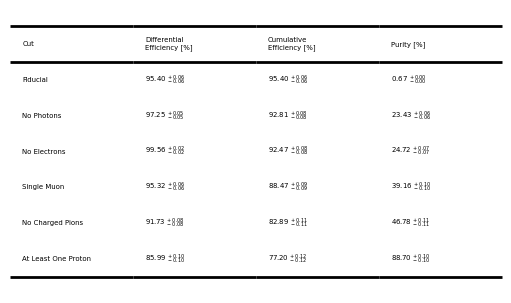

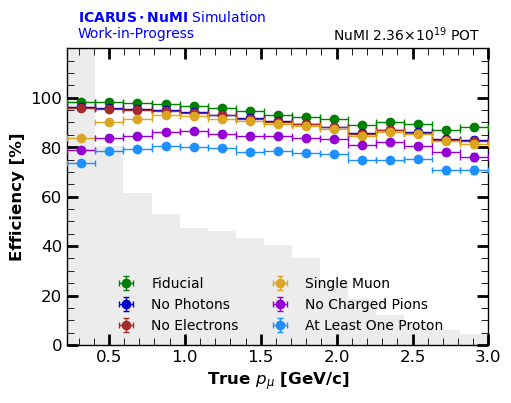

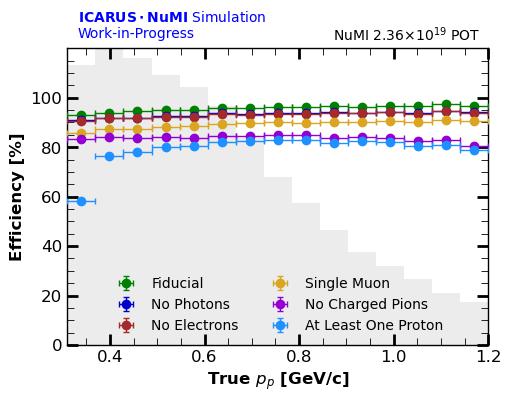

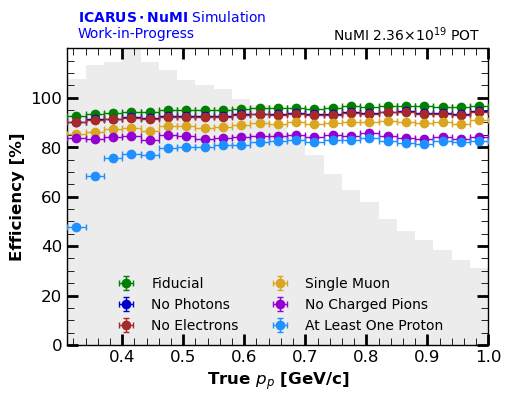

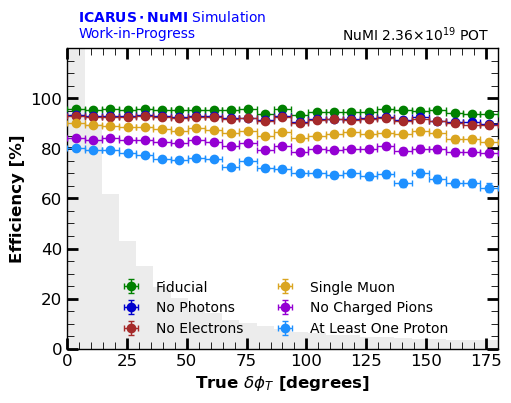

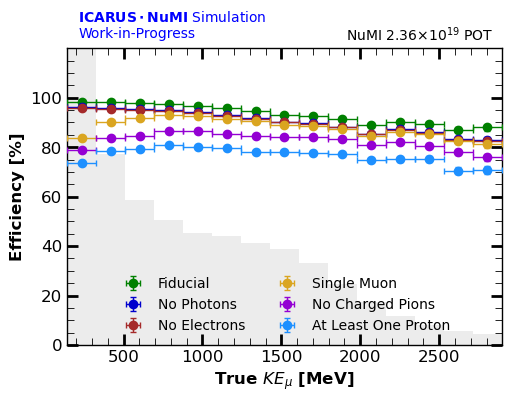

In [4]:
analysis = Analysis(ana_directory + '/Efficiency/efficiency.toml', data_file)
analysis.run(close_figs=False)


Processing systematics for sample: signal
Setting weight for signal to 1.00e+00


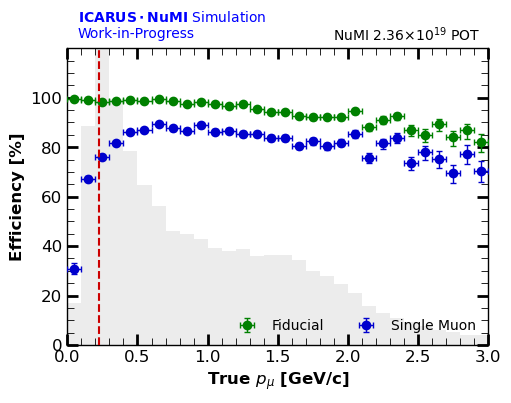

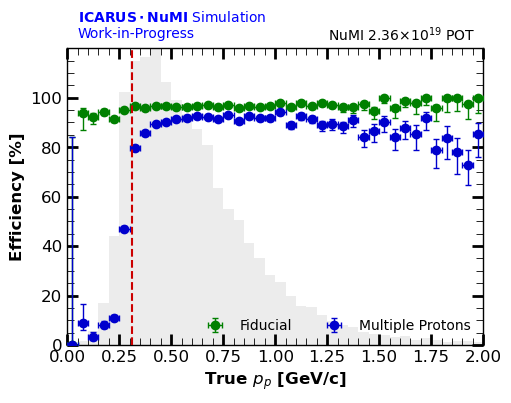

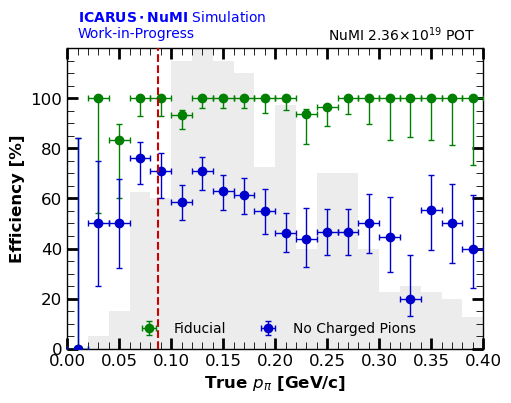

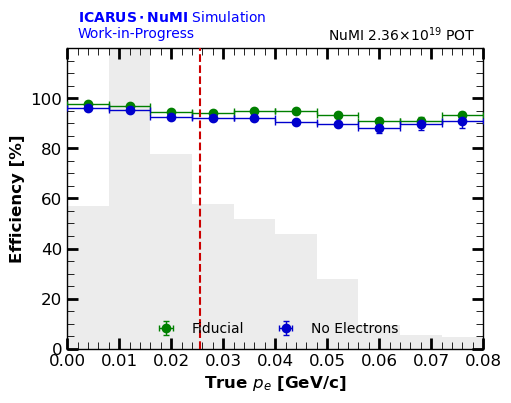

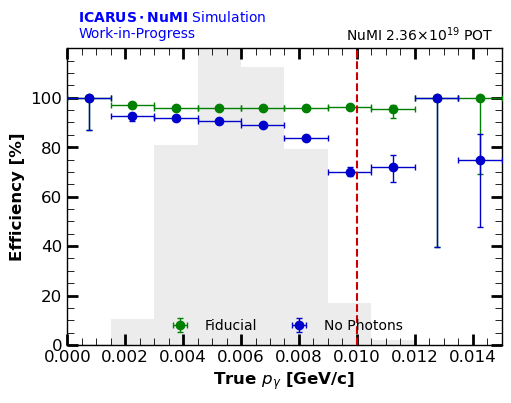

In [4]:
# Per-cut threshold-motivation plots (thresholds removed from signal definition)
cuts_data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained_cuts.root'
analysis = Analysis(ana_directory + '/Efficiency/efficiency_cuts.toml', cuts_data_file)
analysis.run(close_figs=False)

In [ ]:
# Cut-flow table with the flash-time stage -- reviewer question (London, 863)
#
# The published Table 5.3 has no flash-time row: the spineplot progression
# (efficiency.toml [figure.artists.cuts]) simulates cuts from multiplicity
# branches and never included reco_flash_cut. The preselection tree stores
# every selection cut as a branch, so the full progression INCLUDING flash
# can be computed without any new production.
#
# Conventions (all candidate-level, one consistent denominator):
#   purity   = signal candidates / all candidates at each stage
#   diff eff = signal candidates retained by each cut
#   cum ret  = signal candidates at stage / signal candidates at fiducial
# Note the preselection tree is reco-mode (one entry per reconstructed
# candidate), so a true event split into several slices counts more than
# once; there is no per-event ID in this tree to deduplicate. The final
# stage agrees with the selected/signal tree efficiency (77.2%), so the
# duplicates die off as the cuts tighten.

import uproot
import numpy as np
from scipy import stats as st

FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained_wRock.root"
)
TREE = "events/cv/preselection"
SIG = [0, 1, 3, 4]

t = uproot.open(FILE)[TREE]
a = t.arrays(["true_category", "reco_flash_cut", "reco_no_photons",
              "reco_no_electrons", "reco_single_muon",
              "reco_no_charged_pions", "reco_no_protons"], library="np")
c = a["true_category"]

stages = [("Fiducial", None),
          ("Flash time", a["reco_flash_cut"] == 1),
          ("No Photons", a["reco_no_photons"] == 1),
          ("No Electrons", a["reco_no_electrons"] == 1),
          ("Single Muon", a["reco_single_muon"] == 1),
          ("No Charged Pions", a["reco_no_charged_pions"] == 1),
          ("At Least One Proton", a["reco_no_protons"] == 0)]

def bayes_interval(k, n):
    """Central 68.27% interval of the flat-prior binomial posterior."""
    lo = st.beta.ppf((1 - 0.6827) / 2, k + 1, n - k + 1)
    hi = st.beta.ppf((1 + 0.6827) / 2, k + 1, n - k + 1)
    map_ = k / n
    return 100 * map_, 100 * (map_ - lo), 100 * (hi - map_)

mask = np.ones(len(c), bool)
prev_sig, sig0 = None, None
print(f"{'stage':>20} {'N':>9} {'purity [%]':>16} {'diff eff [%]':>16} {'cum ret [%]':>11}")
for name, cut in stages:
    if cut is not None:
        mask &= cut
    N = int(mask.sum())
    s = int(np.isin(c[mask], SIG).sum())
    if sig0 is None:
        sig0 = s
    p, pdn, pup = bayes_interval(s, N)
    if prev_sig:
        e, edn, eup = bayes_interval(s, prev_sig)
        eff = f"{e:6.2f} +{eup:.2f}/-{edn:.2f}"
    else:
        eff = "--"
    print(f"{name:>20} {N:>9} {p:7.2f} +{pup:.2f}/-{pdn:.2f} {eff:>16} {100*s/sig0:>10.2f}")
    prev_sig = s
